In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   'black',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.color':       'black',
    'ytick.color':       'black',
    'text.color':        'black',
    'grid.color':        '#dddddd',
    'grid.linewidth':    0.6,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#cccccc',
    'legend.framealpha': 1.0,
    'font.family':       'sans-serif',
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
})

In [41]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
BASE = "/resnick/groups/Proberlab/yun/lightsheet/hcrt-trpv1_hcrt-h2b-g8m_120min"

FISH_PATHS = [
    f"{BASE}/260426_hcrt-trpv1_hcrt-h2b-g8m_csn_10uM_fish1/hcrt_all.csv",
    f"{BASE}/260426_hcrt-trpv1_hcrt-h2b-g8m_csn_10uM_fish2/hcrt_all.csv",
    f"{BASE}/260426_hcrt-trpv1_hcrt-h2b-g8m_csn_10uM_fish3/hcrt_all.csv",
]
FISH_LABELS = ["fish1", "fish2", "fish3"]

TOTAL_VOLS  = 7200   # 120 min @ 1 vol/sec
CSN_ONSET   = 2700   # 45 min
CSN_END     = 5400   # 90 min

CHAMBER_VOL = 15.0   # mL
FLOW_RATE   = 4.0    # mL/min
TAU_S       = (CHAMBER_VOL / FLOW_RATE) * 60   # → 225 s

In [42]:
# ── INSPECT (run this first to see the actual column layout) ──────────────────
df0 = pd.read_csv(FISH_PATHS[0])
print(f"Shape:        {df0.shape}")
print(f"All columns:  {df0.columns.tolist()}")
df0.head(3)

Shape:        (7200, 2)
All columns:  ['Frame', 'Mean']


,Frame,Mean
0,1,108.13953
1,2,107.97493
2,3,107.97820


In [43]:
# ── LOAD → Z-SCORE ON BASELINE ──────────────────────────────────────────────
# CSV is already mean-averaged: columns ['Frame', 'Mean'], 7200 rows, Frame is 1-indexed

fish_z = {}

for label, path in zip(FISH_LABELS, FISH_PATHS):
    df    = pd.read_csv(path)
    trace = df['Mean'].values  # already sorted by Frame, length = TOTAL_VOLS

    mu    = trace[:CSN_ONSET].mean()
    sigma = trace[:CSN_ONSET].std(ddof=1)
    fish_z[label] = (trace - mu) / sigma

    print(f"{label}: μ={mu:.4f}  σ={sigma:.4f}  "
          f"→ baseline z mean={fish_z[label][:CSN_ONSET].mean():.4f}")

fish1: μ=107.4470  σ=0.2580  → baseline z mean=-0.0000
fish2: μ=105.6690  σ=0.1380  → baseline z mean=-0.0000
fish3: μ=106.3958  σ=0.1096  → baseline z mean=0.0000


In [44]:
# ── CROSS-FISH AVERAGE ± SEM AND CAPSAICIN MODEL ──────────────────────────────
z_mat  = np.stack(list(fish_z.values()))   # (3, T)
mean_z = z_mat.mean(axis=0)
sem_z  = z_mat.std(axis=0, ddof=1) / np.sqrt(3)

t_sec    = np.arange(TOTAL_VOLS, dtype=float)
t_min    = t_sec / 60.0
csn_conc = np.zeros(TOTAL_VOLS)
csn_conc[CSN_ONSET:CSN_END] = 1 - np.exp(-(t_sec[CSN_ONSET:CSN_END] - CSN_ONSET) / TAU_S)
C_end = csn_conc[CSN_END - 1]
csn_conc[CSN_END:] = C_end * np.exp(-(t_sec[CSN_END:] - CSN_END) / TAU_S)

print(f"τ = {TAU_S:.0f} s = {TAU_S/60:.2f} min  |  "
      f"drug phase = {(CSN_END - CSN_ONSET) / TAU_S:.1f}τ  |  C_end = {C_end:.6f}")

τ = 225 s = 3.75 min  |  drug phase = 12.0τ  |  C_end = 0.999994


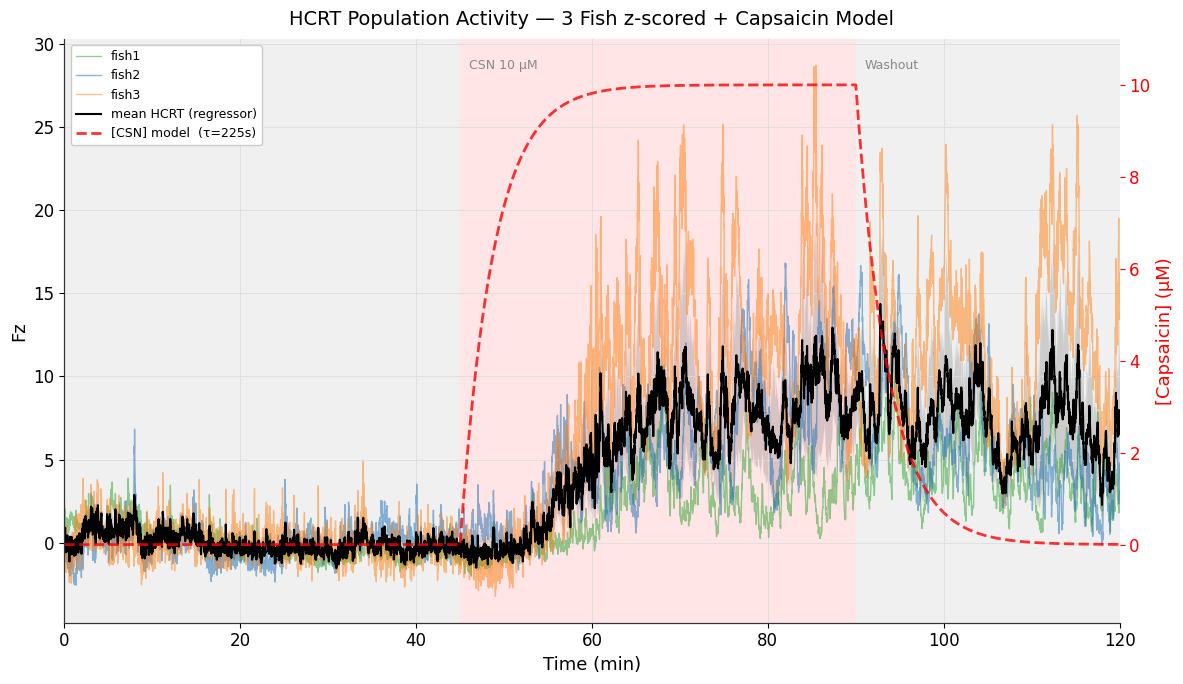

In [49]:
# ── PLOT ──────────────────────────────────────────────────────────────────────
FISH_COLORS = ['#2ca02c', '#1a6eb5', '#ff7f0e']

fig, ax = plt.subplots(figsize=(12, 7))
ax2 = ax.twinx()

# phase bands
ax.axvspan(0,              CSN_ONSET/60,  color='#f0f0f0', alpha=1.0, zorder=0)
ax.axvspan(CSN_ONSET/60,   CSN_END/60,    color='#ffe5e5', alpha=1.0, zorder=0)
ax.axvspan(CSN_END/60,     TOTAL_VOLS/60, color='#f0f0f0', alpha=1.0, zorder=0)

# individual fish
for (label, z), col in zip(fish_z.items(), FISH_COLORS):
    ax.plot(t_min, z, color=col, lw=1.0, alpha=0.5, label=label)

# SEM ribbon + mean
ax.fill_between(t_min, mean_z - sem_z, mean_z + sem_z,
                color='black', alpha=0.15, linewidth=0)
ax.plot(t_min, mean_z, color='black', lw=1.5, label='mean HCRT (regressor)')

# capsaicin model
ax2.plot(t_min, csn_conc * 10.0, color='red', lw=2, ls='--', alpha=0.8,
         label=f'[CSN] model  (τ={TAU_S:.0f}s)')
ax2.set_ylim(-1.7, 11.0)
ax2.set_ylabel('[Capsaicin] (µM)', color='red')
ax2.tick_params(axis='y', colors='red')
ax2.spines['right'].set_edgecolor('red')
ax2.spines['top'].set_visible(False)

# phase labels
ylim = ax.get_ylim()
for x, lbl in [(1, 'Baseline (E3)'), (CSN_ONSET/60+1, 'CSN 10 µM'), (CSN_END/60+1, 'Washout')]:
    ax.text(x, ylim[1]*0.96, lbl, fontsize=9, color='#888888', va='top')

ax.set_xlabel('Time (min)')
ax.set_ylabel('Fz')
ax.set_xlim(0, TOTAL_VOLS/60)
ax.grid(True, alpha=1.0)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc='upper left', fontsize=9)

plt.title('HCRT Population Activity — 3 Fish z-scored + Capsaicin Model', pad=10)
plt.tight_layout()
plt.savefig(f'{BASE}/hcrt_regressor_overlay.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [50]:
# ── SANITY + SAVE REGRESSOR ───────────────────────────────────────────────────
print(f"Baseline mean z  (→ ~0):  {mean_z[:CSN_ONSET].mean():.4f}")
print(f"CSN peak z:               {mean_z[CSN_ONSET:CSN_END].max():.4f}")
print(f"Washout mean z:           {mean_z[CSN_END:].mean():.4f}")

out = pd.DataFrame({"volume": np.arange(TOTAL_VOLS), "time_sec": t_sec,
                    "time_min": t_min, "hcrt_mean_z": mean_z,
                    "hcrt_sem_z": sem_z, "csn_conc_model": csn_conc})
for label, z in fish_z.items():
    out[f"{label}_z"] = z

out.to_csv("hcrt_regressor.csv", index=False, float_format="%.6f")
print(f"Saved → hcrt_regressor.csv  ({out.shape[0]} rows × {out.shape[1]} cols)")

Baseline mean z  (→ ~0):  0.0000
CSN peak z:               12.9427
Washout mean z:           7.4707
Saved → hcrt_regressor.csv  (7200 rows × 9 cols)


In [51]:
# ── COMPUTE F_TONIC / F_PHASIC FROM RAW F ────────────────────────────────────
# F_tonic  = rolling 20th-percentile of raw F (window=600 vols, centered)
# F_phasic = (F - F_tonic) / F_tonic
# Both z-scored on baseline (vols 0:CSN_ONSET) before plotting

TONIC_WINDOW      = 600    # vols (~10 min)
TONIC_PERCENTILE  = 0.20   # 20th percentile

fish_tonic  = {}
fish_phasic = {}

for label, path in zip(FISH_LABELS, FISH_PATHS):
    raw = pd.read_csv(path)['Mean'].values

    # rolling percentile (centered, same as voluseg convention)
    f_tonic = (pd.Series(raw)
                 .rolling(TONIC_WINDOW, center=True, min_periods=1)
                 .quantile(TONIC_PERCENTILE)
                 .values)
    f_phasic = (raw - f_tonic) / f_tonic

    # z-score each on baseline
    for sig, store in [(f_tonic, fish_tonic), (f_phasic, fish_phasic)]:
        mu, sigma = sig[:CSN_ONSET].mean(), sig[:CSN_ONSET].std(ddof=1)
        store[label] = (sig - mu) / sigma

    print(f"{label}  tonic baseline z={fish_tonic[label][:CSN_ONSET].mean():.4f}  "
          f"phasic baseline z={fish_phasic[label][:CSN_ONSET].mean():.4f}")

fish1  tonic baseline z=0.0000  phasic baseline z=0.0000
fish2  tonic baseline z=0.0000  phasic baseline z=-0.0000
fish3  tonic baseline z=0.0000  phasic baseline z=-0.0000


In [79]:
# ── SHARED PLOT HELPER ────────────────────────────────────────────────────────
def plot_traces(fish_dict, title, ylabel, fname):
    FISH_COLORS = ['#2ca02c', '#1a6eb5', '#ff7f0e']
    z_mat  = np.stack(list(fish_dict.values()))
    mean_z = z_mat.mean(axis=0)
    sem_z  = z_mat.std(axis=0, ddof=1) / np.sqrt(3)

    fig, ax = plt.subplots(figsize=(12, 7))
    ax2 = ax.twinx()

    ax.axvspan(0,              CSN_ONSET/60,  color='#f0f0f0', alpha=1.0, zorder=0)
    ax.axvspan(CSN_ONSET/60,   CSN_END/60,    color='#ffe5e5', alpha=1.0, zorder=0)
    ax.axvspan(CSN_END/60,     TOTAL_VOLS/60, color='#f0f0f0', alpha=1.0, zorder=0)

    for (label, z), col in zip(fish_dict.items(), FISH_COLORS):
        ax.plot(t_min, z, color=col, lw=1.0, alpha=0.4, label=label)

    ax.fill_between(t_min, mean_z - sem_z, mean_z + sem_z,
                    color='black', alpha=0.15, linewidth=0)
    ax.plot(t_min, mean_z, color='black', lw=1.5, label='mean (regressor)')

    ax2.plot(t_min, csn_conc * 10.0, color='red', lw=1.5, ls='--', alpha=0.8,
             label=f'[CSN] model  (τ={TAU_S:.0f}s)')
    ax2.set_ylim(-1.5, 11.0)
    ax2.set_ylabel('[Capsaicin] (µM)', color='red')
    ax2.tick_params(axis='y', colors='red')
    ax2.spines['right'].set_edgecolor('red')
    ax2.spines['top'].set_visible(False)

    ylim = ax.get_ylim()
    for x, lbl in [(1, 'Baseline (E3)'), (CSN_ONSET/60+1, 'CSN 10 µM'), (CSN_END/60+1, 'Washout')]:
        ax.text(x, ylim[1]*0.96, lbl, fontsize=9, color='#888888', va='top')

    ax.set_xlabel('Time (min)')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, TOTAL_VOLS/60)
    ax.set_ylim(-5.5, )
    ax.grid(True, alpha=1.0)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, loc='upper left', fontsize=9)
    plt.title(title, pad=10)
    plt.tight_layout()
    plt.savefig(f'{BASE}/{fname}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {fname}')

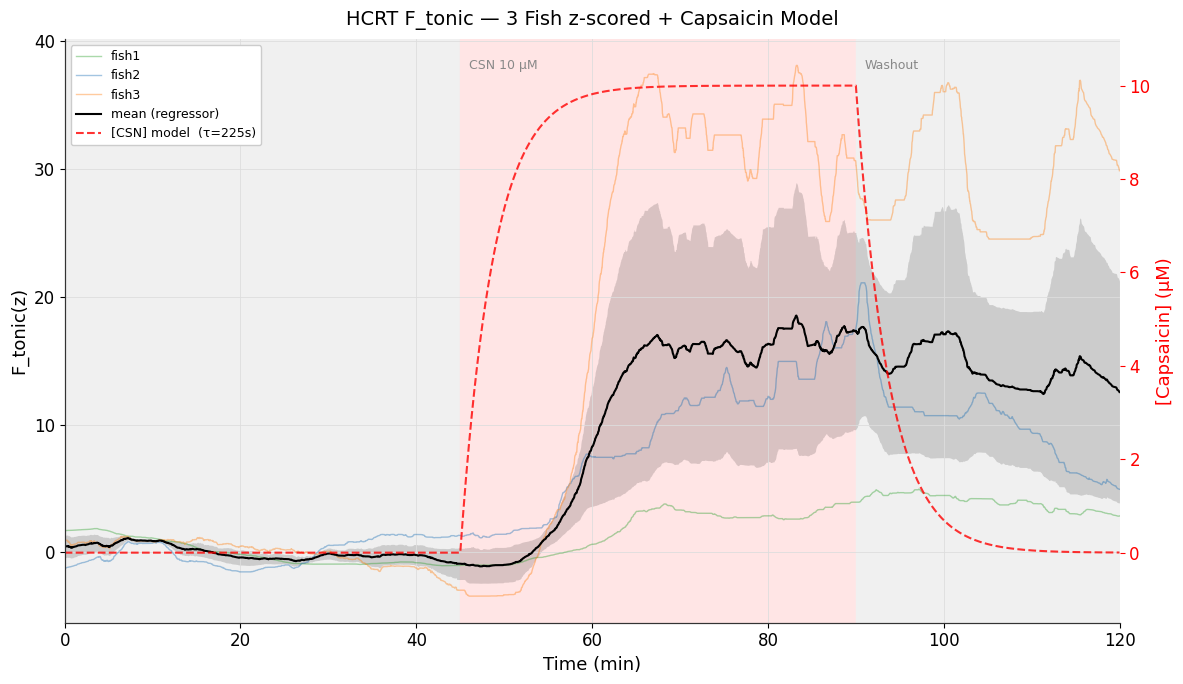

Saved → hcrt_tonic_overlay.png


In [80]:
plot_traces(
    fish_tonic,
    title  = 'HCRT F_tonic — 3 Fish z-scored + Capsaicin Model',
    ylabel = 'F_tonic(z)',
    fname  = 'hcrt_tonic_overlay.png',
)

In [77]:
# ── SHARED PLOT HELPER ────────────────────────────────────────────────────────
def plot_traces(fish_dict, title, ylabel, fname):
    FISH_COLORS = ['#2ca02c', '#1a6eb5', '#ff7f0e']
    z_mat  = np.stack(list(fish_dict.values()))
    mean_z = z_mat.mean(axis=0)
    sem_z  = z_mat.std(axis=0, ddof=1) / np.sqrt(3)

    fig, ax = plt.subplots(figsize=(12, 7))
    ax2 = ax.twinx()

    ax.axvspan(0,              CSN_ONSET/60,  color='#f0f0f0', alpha=1.0, zorder=0)
    ax.axvspan(CSN_ONSET/60,   CSN_END/60,    color='#ffe5e5', alpha=1.0, zorder=0)
    ax.axvspan(CSN_END/60,     TOTAL_VOLS/60, color='#f0f0f0', alpha=1.0, zorder=0)

    for (label, z), col in zip(fish_dict.items(), FISH_COLORS):
        ax.plot(t_min, z, color=col, lw=1.0, alpha=0.3, label=label)

    ax.fill_between(t_min, mean_z - sem_z, mean_z + sem_z,
                    color='black', alpha=0.15, linewidth=0)
    ax.plot(t_min, mean_z, color='black', lw=1, label='mean (regressor)')

    ax2.plot(t_min, csn_conc * 10.0, color='red', lw=1.5, ls='--', alpha=0.8,
             label=f'[CSN] model  (τ={TAU_S:.0f}s)')
    ax2.set_ylim(-2.8, 11.0)
    ax2.set_ylabel('[Capsaicin] (µM)', color='red')
    ax2.tick_params(axis='y', colors='red')
    ax2.spines['right'].set_edgecolor('red')
    ax2.spines['top'].set_visible(False)

    ylim = ax.get_ylim()
    for x, lbl in [(1, 'Baseline (E3)'), (CSN_ONSET/60+1, 'CSN 10 µM'), (CSN_END/60+1, 'Washout')]:
        ax.text(x, ylim[1]*0.96, lbl, fontsize=9, color='#888888', va='top')

    ax.set_xlabel('Time (min)')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, TOTAL_VOLS/60)
    ax.set_ylim(-5.5, )
    ax.grid(True, alpha=1.0)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, loc='upper left', fontsize=9)
    plt.title(title, pad=10)
    plt.tight_layout()
    plt.savefig(f'{BASE}/{fname}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {fname}')

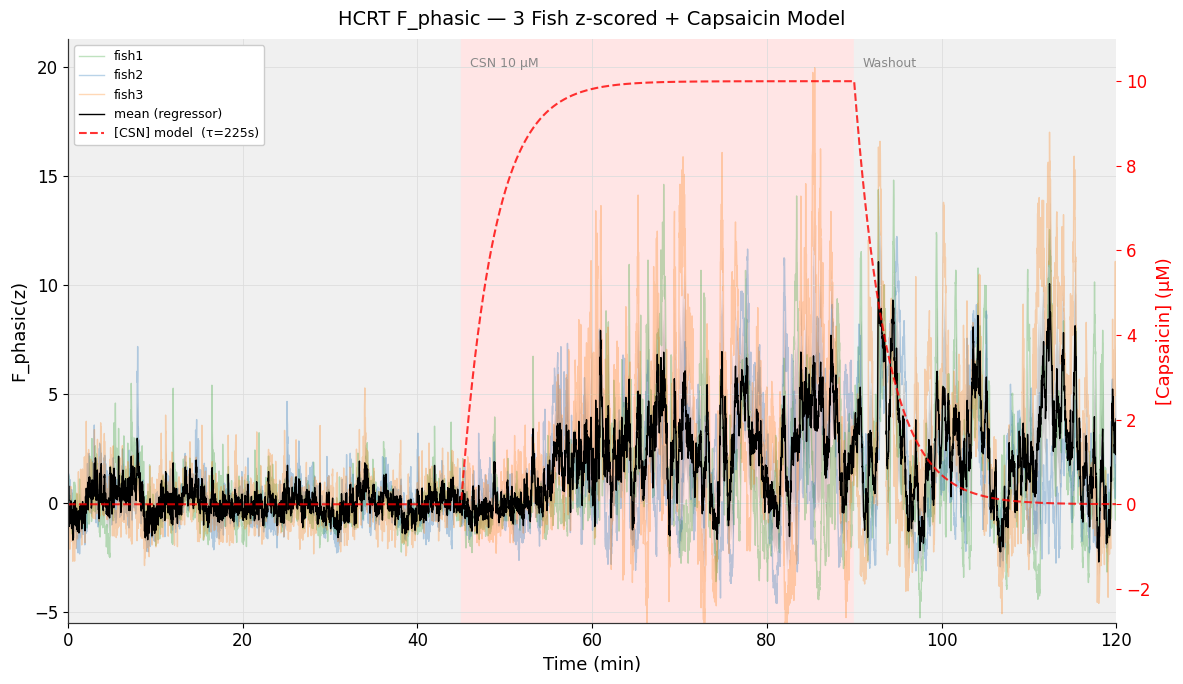

Saved → hcrt_phasic_overlay.png


In [78]:
plot_traces(
    fish_phasic,
    title  = 'HCRT F_phasic — 3 Fish z-scored + Capsaicin Model',
    ylabel = 'F_phasic(z)',
    fname  = 'hcrt_phasic_overlay.png',
)